In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score

In [2]:
!pip install xgboost

  Using cached xgboost-3.2.0-py3-none-win_amd64.whl.metadata (2.1 kB)
Using cached xgboost-3.2.0-py3-none-win_amd64.whl (101.7 MB)


In [4]:
df = pd.read_csv("../../data/weatherAUS_ForModel.csv")

X = df.drop(columns=["RainTomorrow", "Date", "SeasonName"], errors="ignore")
y = df["RainTomorrow"]

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [6]:
#calcul de déséquilibre
neg = np.sum(y_train == 0)
pos = np.sum(y_train == 1)
ratio = neg / pos

Gridsearch

In [7]:
param_grid = {
    "max_depth": [3, 5, 7],
    "learning_rate": [0.05, 0.1],
    "n_estimators": [200, 300]
}

grid = GridSearchCV(
    XGBClassifier(
        scale_pos_weight=ratio,
        eval_metric="logloss",
        random_state=42
    ),
    param_grid,
    cv=3,
    scoring="roc_auc",
    n_jobs=-1
)

In [8]:
grid.fit(X_train, y_train)
print("Best parameters :", grid.best_params_)
print("Best score :", grid.best_score_)

Best parameters : {'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 300}
Best score : 0.8899289921613113


Une recherche d’hyperparamètres a permis d’identifier une configuration optimale du modèle XGBoost (max_depth=7, learning_rate=0.1, n_estimators=300), améliorant significativement les performances avec un ROC-AUC de 0.889.

In [9]:
best_model = XGBClassifier(
    learning_rate=0.1,
    max_depth=7,
    n_estimators=300,
    scale_pos_weight=ratio,
    eval_metric="logloss",
    random_state=42
)

best_model.fit(X_train, y_train)

y_proba = best_model.predict_proba(X_test)[:,1]
threshold = 0.45
y_pred = (y_proba >= threshold).astype(int)



print("ROC-AUC :", roc_auc_score(y_test, y_proba))
print(classification_report(y_test, y_pred))

ROC-AUC : 0.8942634086113057
              precision    recall  f1-score   support

           0       0.93      0.83      0.88     21757
           1       0.57      0.79      0.66      6262

    accuracy                           0.82     28019
   macro avg       0.75      0.81      0.77     28019
weighted avg       0.85      0.82      0.83     28019



La phase de tuning a permis d’optimiser les hyperparamètres du modèle XGBoost, améliorant ainsi ses performances globales.

Avant tuning, le modèle obtenait un ROC-AUC élevé (~0.89), mais cette estimation était optimiste car basée sur un simple découpage des données.

La validation croisée a révélé une performance plus réaliste (ROC-AUC ≈ 0.83) ainsi qu’une variabilité modérée, indiquant une certaine sensibilité du modèle aux données.

Après optimisation, le modèle atteint un ROC-AUC de 0.894, tout en améliorant la détection de la classe minoritaire (recall = 0.79).

Ces résultats montrent que le tuning permet non seulement d’améliorer les performances, mais aussi d’obtenir un modèle plus robuste et mieux adapté au problème.

Feature importance

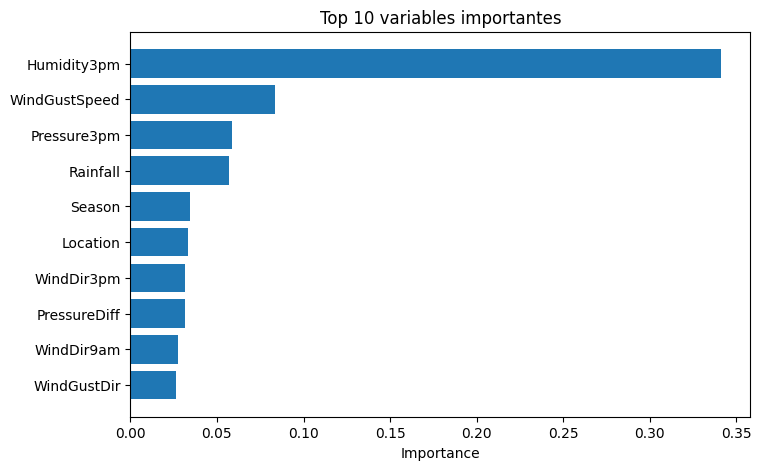

In [10]:
import matplotlib.pyplot as plt
import numpy as np

# Feature importance
importances = best_model.feature_importances_

indices = np.argsort(importances)[-10:]

plt.figure(figsize=(8,5))
plt.barh(range(len(indices)), importances[indices])
plt.yticks(range(len(indices)), X.columns[indices])
plt.title("Top 10 variables importantes")
plt.xlabel("Importance")
plt.show()

Analyse des erreurs

In [11]:
fp = (y_test == 0) & (y_pred == 1)
fn = (y_test == 1) & (y_pred == 0)

print("Faux positifs :", fp.sum())
print("Faux négatifs :", fn.sum())

Faux positifs : 3726
Faux négatifs : 1317


L’analyse des erreurs montre que le modèle génère davantage de faux positifs (3726) que de faux négatifs (1317). Cela indique qu’il privilégie la détection des événements de pluie, même au prix de fausses alertes. Ce comportement est pertinent dans ce contexte, où il est préférable de ne pas manquer un événement de pluie.
Les faux positifs peuvent correspondre à des situations météorologiques proches de la pluie (forte humidité, pression basse), ce qui explique leur fréquence.

In [12]:
fp_data = X_test[fp]
fn_data = X_test[fn]

print("Exemples Faux positifs :")
print(fp_data.head())

print("Exemples Faux négatifs :")
print(fn_data.head())

Exemples Faux positifs :
        Humidity3pm  Humidity9am  Location  MaxTemp  MinTemp  Month  \
21728          67.0         63.0      27.0     18.4     14.1      8   
75218          30.0         50.0      44.0     23.5     13.9     10   
10343          67.0         64.0      11.0     29.5     19.9      3   
72518          78.0         30.0      33.0     26.1     12.8     10   
123991         46.0         36.0      43.0     28.6     17.4      9   

        Pressure3pm  Pressure9am  Rainfall  Temp3pm  ...  WindDir9am  \
21728        1017.6       1019.7       0.2     17.1  ...        12.0   
75218        1015.3       1018.1       0.0     22.9  ...         5.0   
10343        1015.6       1019.3       1.2     27.1  ...         6.0   
72518        1011.4       1007.5       0.0     17.2  ...         6.0   
123991       1015.6       1017.4       0.0     23.2  ...         5.0   

        WindGustDir  WindGustSpeed  WindSpeed3pm  WindSpeed9am  RainToday  \
21728          12.0           48.0    

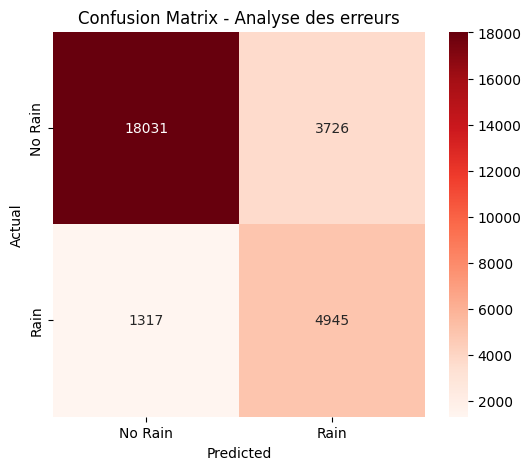

In [19]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Reds",
    xticklabels=["No Rain", "Rain"],
    yticklabels=["No Rain", "Rain"]
)

plt.title("Confusion Matrix - Analyse des erreurs")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

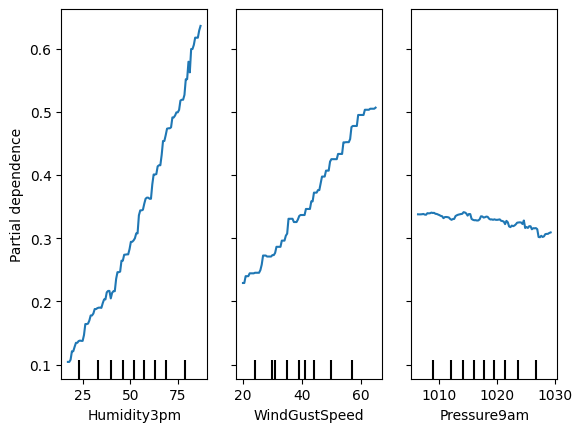

In [21]:
from sklearn.inspection import PartialDependenceDisplay

features = ["Humidity3pm","WindGustSpeed", "Pressure9am"]

PartialDependenceDisplay.from_estimator(
    best_model,
    X,
    features
)

plt.show()

L’humidité à 15h est fortement corrélée à la probabilité de pluie. Une augmentation de cette variable entraîne une hausse significative du risque de précipitation.

Une augmentation de la vitesse des rafales de vent est associée à une probabilité plus élevée de pluie, ce qui reflète des conditions météorologiques instables.

Une baisse de la pression atmosphérique est associée à une augmentation de la probabilité de pluie, ce qui est cohérent avec les principes météorologiques.

PR COURBE

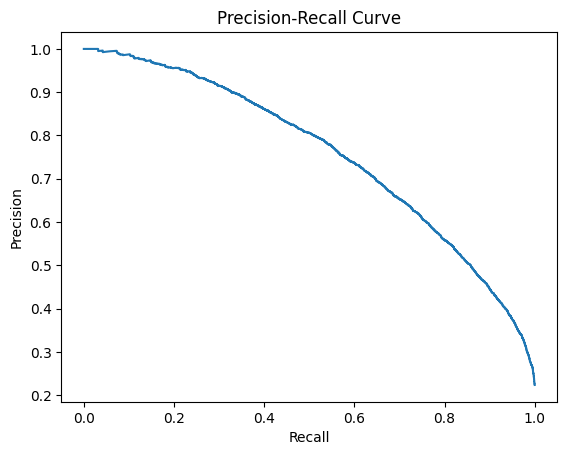

In [13]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

precision, recall, _ = precision_recall_curve(y_test, y_proba)

plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.show()

La courbe Precision-Recall montre un compromis classique entre précision et rappel. Lorsque le recall augmente, la précision diminue, ce qui est attendu dans un problème déséquilibré. Le modèle présente de bonnes performances globales, avec une capacité satisfaisante à détecter les événements de pluie tout en maintenant une précision raisonnable.